Importing necessary Libraries

In [34]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

In [35]:
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense
from tensorflow.keras.callbacks import TensorBoard
import tensorflow as tf

In [36]:
holistic_mp = mp.solutions.holistic # Holistic model
drawing = mp.solutions.drawing_utils # Drawing utilities

In [37]:
def detection_mp(image,model):
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image,cv2.COLOR_RGB2BGR)
    return image,results

In [38]:
def draw_styled_landmarks(image,results):
    
    drawing.draw_landmarks(image,results.pose_landmarks, holistic_mp.POSE_CONNECTIONS,
                             drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
                             drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             )
    
    drawing.draw_landmarks(image,results.left_hand_landmarks, holistic_mp.HAND_CONNECTIONS,
                             drawing.DrawingSpec(color=(121,22,76), thickness=1, circle_radius=4),
                             drawing.DrawingSpec(color=(121,44,250), thickness=1, circle_radius=2)
                             )
    
    drawing.draw_landmarks(image,results.right_hand_landmarks, holistic_mp.HAND_CONNECTIONS,
                             drawing.DrawingSpec(color=(245,117,66), thickness=1, circle_radius=1),
                             drawing.DrawingSpec(color=(245,66,230), thickness=1, circle_radius=1)
                             )

In [39]:
def keypoints_extract(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([lh,rh,pose])

In [40]:
cap = cv2.VideoCapture(0)
# Set mediapipe model
with holistic_mp.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = detection_mp(frame, holistic)
        print(results)

        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()


<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [41]:
DATA_PATH = os.path.join('Data_set')
#Actions
actions = np.array(['hello','thanks','yes'])
#30 videos worth of data
no_sequences = 30
#30 frames
sequence_length = 30

In [42]:
for action in actions:
    for sequence in range(no_sequences):
        try:
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass


In [43]:
cap = cv2.VideoCapture(0)

#Mediapipe Model
with holistic_mp.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    #Loop through Actions
    for action in actions:
        #Loop through Videos
        for sequence in range(no_sequences):
            #Loop through video length aka sequence length
            for frame_num in range(sequence_length):
                
        
                #Read Feed
                ret, frame = cap.read()

                #Make detections
                image,results = detection_mp(frame,holistic)

                #Draw Styled Landmarks
                draw_styled_landmarks(image,results)
                
                #Wait Logic
                if frame_num==0:
                    cv2.putText(image,'Starting Collection',(120,200),
                                cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,0),4,cv2.LINE_AA)
                    cv2.putText(image,'Collecting frames for {} Video Number {}'.format(action,sequence),(15,12),
                                cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1,cv2.LINE_AA)
                    cv2.waitKey(2000)
                
                else:
                    cv2.putText(image,'Collecting frames for {} Video Number {}'.format(action,sequence),(15,12),
                                cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,0,255),1,cv2.LINE_AA)

                #NEW Export keypoints
                keypoints = keypoints_extract(results)
                npy_path = os.path.join(DATA_PATH,action,str(sequence), str(frame_num))
                np.save(npy_path,keypoints)
                
                #Show to Screen
                cv2.imshow('OpenCV feed', image)

                #Breaking the Feed
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

    cap.release()
    cv2.destroyAllWindows() 

In [44]:
label_map = {label:num for num, label in enumerate(actions)}

In [45]:
label_map

{'hello': 0, 'thanks': 1, 'yes': 2}

In [46]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH,action, str(sequence),"{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [47]:
X = np.array(sequences)
y = to_categorical(labels).astype(int)

In [48]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size = 0.05)

In [49]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir = log_dir)

In [50]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,258)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [51]:
res = [.2,0.7,.01]
print(actions[np.argmax(res)])

thanks


In [52]:
model.compile(optimizer = 'Adam',loss='categorical_crossentropy',metrics=['categorical_accuracy'])

In [53]:
history = model.fit(x_train,y_train,epochs = 2000, callbacks=[tb_callback])

Epoch 1/2000
3/3 [==============================] - 5s 53ms/step - loss: 1.0962 - categorical_accuracy: 0.2941
Epoch 2/2000
3/3 [==============================] - 0s 45ms/step - loss: 0.9495 - categorical_accuracy: 0.5059
Epoch 3/2000
3/3 [==============================] - 0s 55ms/step - loss: 0.8332 - categorical_accuracy: 0.5412
Epoch 4/2000
3/3 [==============================] - 0s 39ms/step - loss: 0.6487 - categorical_accuracy: 0.7412
Epoch 5/2000
3/3 [==============================] - 0s 44ms/step - loss: 0.4683 - categorical_accuracy: 0.7059
Epoch 6/2000
3/3 [==============================] - 0s 53ms/step - loss: 0.3406 - categorical_accuracy: 0.8706
Epoch 7/2000
3/3 [==============================] - 0s 50ms/step - loss: 0.3946 - categorical_accuracy: 0.8235
Epoch 8/2000
3/3 [==============================] - 0s 50ms/step - loss: 0.7486 - categorical_accuracy: 0.7412
Epoch 9/2000
3/3 [==============================] - 0s 50ms/step - loss: 0.5015 - categorical_accuracy: 0.7294
E

In [54]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_3 (LSTM)               (None, 30, 64)            82688     
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           98816     
                                                                 
 lstm_5 (LSTM)               (None, 64)                49408     
                                                                 
 dense_3 (Dense)             (None, 64)                4160      
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 3)                 99        
                                                                 
Total params: 237251 (926.76 KB)
Trainable params: 237

In [55]:
res = model.predict(x_test)


1/1 [==============================] - 0s 332ms/step


In [56]:
print(actions[np.argmax(res[1])])


hello


In [57]:
print(actions[np.argmax(y_test[1])])

hello


In [58]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir = log_dir)

In [59]:
res = [.2, 0.7, .01]

actions[np.argmax(res)]

actions[np.argmax(res[1])]

'hello'

In [60]:
colors = [(245,117,16),(117,245,16),(16,117,245)]
def prob_viz(res,actions,input_frame,colors):
    output_frame = input_frame.copy()
    for num,prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40),colors[num], -1)
        cv2.putText(output_frame,actions[num],(0,85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1,(255,255,255),2,cv2.LINE_AA)
    return output_frame

In [61]:
#New Detection Variables
sequence = []
sentence = []
threshold = .4

cap = cv2.VideoCapture(0)
#Mediapipe Model
with holistic_mp.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        
        #Read Feed
        ret, frame = cap.read()
        
        #Make detections
        image,results = detection_mp(frame,holistic)
        
        #Draw Styled Landmarks
        draw_styled_landmarks(image,results)
        
        #Prediciton Logic
        keypoints = keypoints_extract(results)
        sequence.insert(0,keypoints)
        sequence = sequence[:30]
    
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence,axis=0))[0]
        
        #Visualization
        if res[np.argmax(res)] > threshold:
            if len(sentence) > 0:
                if actions[np.argmax(res)] != sentence[-1]:
                    sentence.append(actions[np.argmax(res)])
            else:
                sentence.append(actions[np.argmax(res)])
        
        if len(sentence)>5:
            sentence = sentence[-5:]
        
        
        #Viz probability
        image = prob_viz(res,actions,image,colors)
        
            
        cv2.rectangle(image,(0,0),(640,40),(245,117,16),-1)
        cv2.putText(image, ' '.join(sentence),(3,30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1,(255,255,255),2,cv2.LINE_AA)
        
        #Show to Screen
        cv2.imshow('OpenCV feed', image)
        
        #Breaking the Feed
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows() 

1/1 [==============================] - 0s 18ms/step


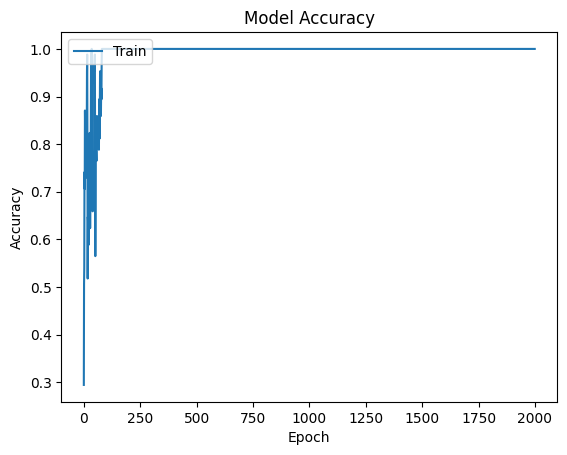

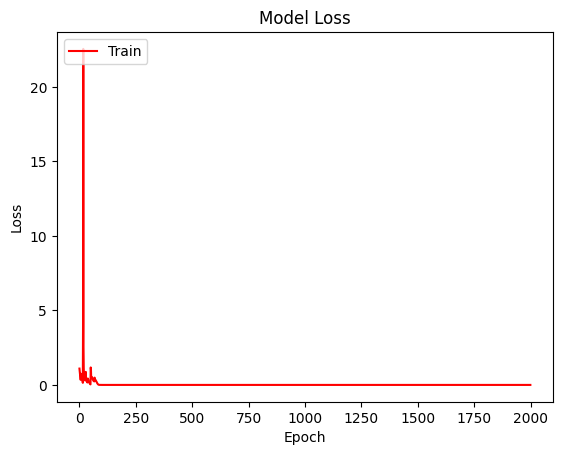

In [62]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['categorical_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()

# Plot loss
plt.plot(history.history['loss'],color = 'r')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')
plt.show()


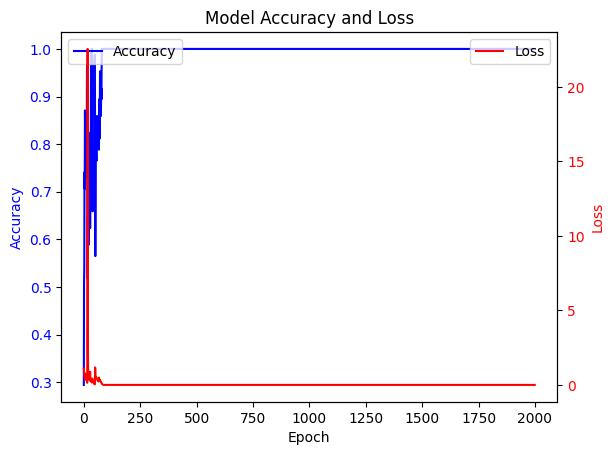

In [63]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots()

# Plot accuracy on the first y-axis
ax1.plot(history.history['categorical_accuracy'], 'b', label='Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.legend(loc='upper left')

# Create a second y-axis
ax2 = ax1.twinx()

# Plot loss on the second y-axis
ax2.plot(history.history['loss'], 'r', label='Loss')
ax2.set_ylabel('Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper right')

# Title for the combined plot
plt.title('Model Accuracy and Loss')

# Display the plot
plt.show()
